# Smoke test 09: DSPS plus toy-nebular continuity-SFH plumbing

This notebook was moved out of `notebooks/validation` because the nebular block is not Cue. It is useful for SFH/NUTS plumbing checks, not full DSPS+Cue scientific validation.

# JADES-like JWST fit with a redshift-aware continuity SFH

This notebook keeps the same kind of simulated JWST observation as the previous JADES-like validation: a NIRSpec/PRISM-like spectrum plus broad-band NIRCam-like photometry.

The change is the SFH model:

- **generator**: delayed parametric SFH on the DSPS cosmic-time clock;
- **fitter**: `continuity_sfh_cosmic_time_module`, with redshift-aware oldest bin ending at `age_universe(z)`.

The goal is to inspect both:

1. the posterior of the usual fit parameters (`log10_mass`, `z`, `logzsol`, `dust2`, `line_scale`);
2. the posterior over the physical SFH, plotted as `SFR(t_lookback)` after multiplying the per-solar-mass SFH by `10**log10_mass`.

This is deliberately a controlled model-mismatch test: we generate from a smooth delayed SFH and fit a binned continuity SFH.

In [1]:
from pathlib import Path
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from dsps import load_ssp_templates

from sedinfer.experimental.jaxcigale import (
    GaussianPhotometricData,
    GaussianSpectralData,
    GaussianSpectroPhotometricData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    build_jax_sed_model,
    calzetti_attenuation_module,
    continuity_sfh_cosmic_time_module,
    delayed_sfh_cosmic_time_module,
    dsps_stellar_module,
    madau_igm_module,
    model_spectrum_on_observed_pixels,
    nebular_emulator_module,
    pixel_edges_from_centers_numpy,
    redshift_module,
    run_numpyro_nuts,
)
from sedinfer.experimental.jaxcigale.core import flat_lcdm_age_gyr_numpy
from sedinfer.experimental.jaxcigale.photometry import AB_FNU_CGS, C_A_PER_S
from sedinfer.experimental.jaxcigale.ssp_data import default_continuum_ssp_path, require_continuum_ssp_path

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True})


def find_repo_root(start):
    path = Path(start).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "sedinfer").is_dir() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate sedinfer repository root.")


REPO_ROOT = find_repo_root(Path.cwd())
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "jades_like_continuity_sfh_fit"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIT_FILE = OUTPUT_DIR / "nuts_jades_like_continuity_sfh_fit.npz"
SUMMARY_FILE = OUTPUT_DIR / "nuts_jades_like_continuity_sfh_fit_summary.json"
ssp_candidate = default_continuum_ssp_path()
if not ssp_candidate.is_absolute():
    ssp_candidate = REPO_ROOT / ssp_candidate
SSP_FILE = require_continuum_ssp_path(ssp_candidate)

RUN_NUTS = os.environ.get("SEDINFER_FORCE_RERUN", "0") == "1" or not FIT_FILE.exists()
NUM_WARMUP = int(os.environ.get("SEDINFER_VALIDATE_NUM_WARMUP", "500"))
NUM_SAMPLES = int(os.environ.get("SEDINFER_VALIDATE_NUM_SAMPLES", "500"))
print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())
print("DSPS SSP file:", SSP_FILE)
print("Output directory:", OUTPUT_DIR)
print("Run NUTS in this execution:", RUN_NUTS)

JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
DSPS SSP file: /Users/gregoire/Documents/Sedfitting/sedinfer-public/outputs/experimental_dsps_fsps_clock_diagnostic/fsps_continuum_ssp_data.h5
Output directory: /Users/gregoire/Documents/Sedfitting/sedinfer-public/notebooks/outputs/jades_like_continuity_sfh_fit
Run NUTS in this execution: True


## Instrument approximations

The spectrum is a binned PRISM-like grid.  I intentionally use a somewhat coarser grid than the previous pure-spectral notebook so the continuity-SFH NUTS run remains interactive.

The broad-band filters are simple trapezoids centered on common NIRCam wide bands. They are not official throughput curves.

Spectrum pixels: 265
Wavelength range: 0.70-5.18 micron
R range: 40.0-326.0


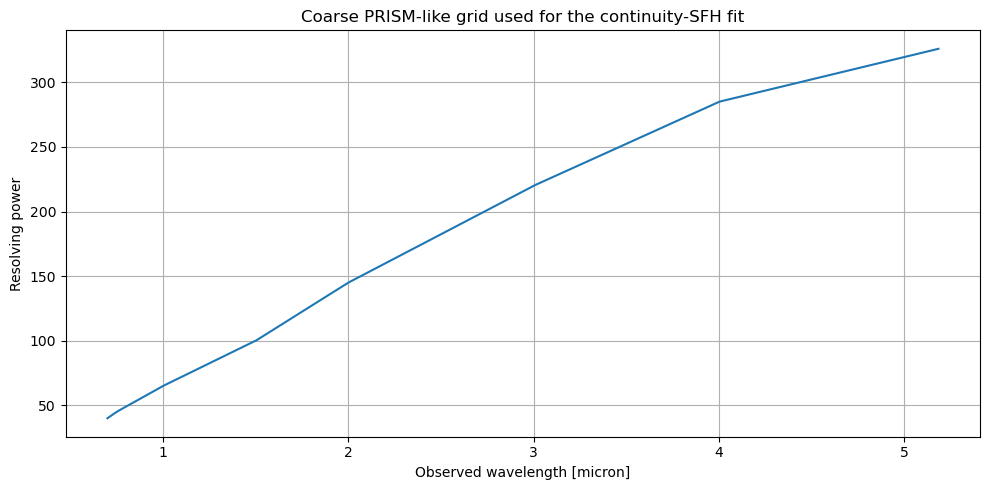

In [2]:
def approximate_nirspec_prism_resolving_power(wave_um):
    wave_um = np.asarray(wave_um, dtype=float)
    anchor_wave = np.array([0.60, 0.75, 1.00, 1.50, 2.00, 3.00, 4.00, 5.30])
    anchor_r = np.array([30.0, 45.0, 65.0, 100.0, 145.0, 220.0, 285.0, 330.0])
    return np.interp(wave_um, anchor_wave, anchor_r)


def make_prism_pixel_grid(wave_min_um=0.70, wave_max_um=5.20, pixels_per_resolution_element=0.85):
    centers = [float(wave_min_um)]
    while centers[-1] < wave_max_um:
        r_here = float(approximate_nirspec_prism_resolving_power(centers[-1]))
        delta_um = centers[-1] / (pixels_per_resolution_element * r_here)
        centers.append(centers[-1] + delta_um)
    centers = np.asarray(centers)
    centers = centers[centers <= wave_max_um]
    return centers * 1.0e4


def trapezoid_filter(center_um, width_um, edge_fraction=0.18, n=96):
    half = 0.5 * width_um
    edge = edge_fraction * width_um
    wave_um = np.linspace(center_um - half, center_um + half, n)
    left = center_um - half + edge
    right = center_um + half - edge
    transmission = np.ones_like(wave_um)
    transmission = np.where(wave_um < left, (wave_um - (center_um - half)) / edge, transmission)
    transmission = np.where(wave_um > right, ((center_um + half) - wave_um) / edge, transmission)
    return wave_um * 1.0e4, np.clip(transmission, 0.0, 1.0)


spectral_wave_a = make_prism_pixel_grid()
spectral_edges_a = pixel_edges_from_centers_numpy(spectral_wave_a)
resolving_power = approximate_nirspec_prism_resolving_power(spectral_wave_a / 1.0e4)

filter_table = pd.DataFrame(
    {
        "name": ["F090W", "F115W", "F150W", "F200W", "F277W", "F356W", "F444W"],
        "center_um": [0.90, 1.15, 1.50, 2.00, 2.77, 3.56, 4.44],
        "width_um": [0.25, 0.30, 0.40, 0.55, 0.75, 0.85, 1.00],
        "five_sigma_depth_ab": [29.4, 29.6, 29.7, 29.7, 29.5, 29.3, 29.1],
    }
)
filter_waves = []
filter_trans = []
for row in filter_table.itertuples(index=False):
    wave, trans = trapezoid_filter(row.center_um, row.width_um)
    filter_waves.append(wave)
    filter_trans.append(trans)
filters = JaxFilterSet.from_curves(filter_table["name"], filter_waves, filter_trans)
filter_effective_wave_a = np.array([
    np.trapezoid(w * t, w) / np.trapezoid(t, w)
    for w, t in zip(filter_waves, filter_trans)
])

print(f"Spectrum pixels: {spectral_wave_a.size}")
print(f"Wavelength range: {spectral_wave_a[0]/1e4:.2f}-{spectral_wave_a[-1]/1e4:.2f} micron")
print(f"R range: {resolving_power.min():.1f}-{resolving_power.max():.1f}")

fig, ax = plt.subplots()
ax.plot(spectral_wave_a / 1e4, resolving_power)
ax.set_xlabel("Observed wavelength [micron]")
ax.set_ylabel("Resolving power")
ax.set_title("Coarse PRISM-like grid used for the continuity-SFH fit")
fig.tight_layout()

## Generator and fitter models

Both models share DSPS stellar emission, the same toy nebular line block, dust, IGM, redshift, spectrum operator, and filter integration.

The only deliberate difference is the SFH module.

In [3]:
def toy_highz_nebular_lines(wave_rest_a, line_scale=1.0, logzsol=-0.5):
    """Toy rest-frame nebular spectrum in Lsun/Angstrom per solar mass."""

    wave = jnp.asarray(wave_rest_a)
    metallicity_factor = 10.0 ** (0.15 * logzsol)
    scale = line_scale * metallicity_factor
    continuum = 3.0e-9 * scale * (wave / 3000.0) ** -0.3

    def gaussian(center_a, sigma_a, equivalent_width_a):
        local_continuum = 2.0e-7 * (center_a / 5500.0) ** -1.4
        amplitude = local_continuum * equivalent_width_a / (jnp.sqrt(2.0 * jnp.pi) * sigma_a)
        return amplitude * jnp.exp(-0.5 * ((wave - center_a) / sigma_a) ** 2)

    lines = scale * (
        gaussian(1215.67, 1.2, 80.0)
        + gaussian(1908.7, 1.5, 25.0)
        + gaussian(3727.0, 2.0, 70.0)
        + gaussian(4102.0, 2.0, 18.0)
        + gaussian(4341.0, 2.0, 25.0)
        + gaussian(4861.0, 2.5, 35.0)
        + gaussian(5007.0, 2.5, 120.0)
    )
    return continuum, lines


ssp_data = load_ssp_templates(fn=str(SSP_FILE))
rest_wave_a = np.linspace(500.0, 5600.0, 620)
base_parameter_names = ["log10_mass", "z", "logzsol", "dust2", "line_scale"]

true_theta_gen = np.array([9.15, 10.0, -0.65, 0.08, 1.25])
fixed_generator_sfh = {
    "tau_gyr": 0.12,
    "tage_fraction": 0.74,
}

parameter_space_gen = JaxParameterSpace(
    names=base_parameter_names,
    priors={
        "log10_mass": UniformJaxPrior(8.0, 10.6),
        "z": UniformJaxPrior(8.5, 11.5),
        "logzsol": UniformJaxPrior(-1.5, 0.2),
        "dust2": UniformJaxPrior(0.0, 0.5),
        "line_scale": UniformJaxPrior(0.1, 3.0),
    },
)

lookback_edges_gyr = np.array([0.0, 0.01, 0.03, 0.10, 0.20])
continuity_parameter_names = base_parameter_names + [f"logsfr_{i}" for i in range(1, lookback_edges_gyr.size)]
parameter_space_fit = JaxParameterSpace(
    names=continuity_parameter_names,
    priors={
        "log10_mass": UniformJaxPrior(8.0, 10.6),
        "z": UniformJaxPrior(9.2, 10.8),
        "logzsol": UniformJaxPrior(-1.5, 0.2),
        "dust2": UniformJaxPrior(0.0, 0.5),
        "line_scale": UniformJaxPrior(0.1, 3.0),
        "logsfr_1": UniformJaxPrior(-2.5, 2.5),
        "logsfr_2": UniformJaxPrior(-2.5, 2.5),
        "logsfr_3": UniformJaxPrior(-2.5, 2.5),
        "logsfr_4": UniformJaxPrior(-2.5, 2.5),
    },
)

common_tail_modules = [
    dsps_stellar_module(ssp_data, separation_age_myr=10.0),
    nebular_emulator_module(toy_highz_nebular_lines, parameter_names=("line_scale", "logzsol")),
    calzetti_attenuation_module(av_parameter="dust2", slope_parameter=None, bump_amplitude_parameter=None),
    madau_igm_module(),
    redshift_module(),
]

model_gen = build_jax_sed_model(
    modules=[
        delayed_sfh_cosmic_time_module(
            n_time=96,
            tau_parameter="tau_gyr",
            tage_parameter="tage_fraction",
            tage_is_fraction_of_universe_age=True,
        ),
        *common_tail_modules,
    ],
    wavelength_grid_a=rest_wave_a,
    filters=filters,
    parameter_space=parameter_space_gen,
    fixed_parameters=fixed_generator_sfh,
)

model_fit = build_jax_sed_model(
    modules=[
        continuity_sfh_cosmic_time_module(lookback_edges_gyr),
        *common_tail_modules,
    ],
    wavelength_grid_a=rest_wave_a,
    filters=filters,
    parameter_space=parameter_space_fit,
    fixed_parameters={"logsfr_0": 0.0},
)

print("Generator parameters:", base_parameter_names)
print("Fitter parameters:", continuity_parameter_names)
print("Continuity lookback edges [Gyr]:", lookback_edges_gyr)
print("Fitted SFH amplitudes are relative to fixed logsfr_0 = 0.")

Generator parameters: ['log10_mass', 'z', 'logzsol', 'dust2', 'line_scale']
Fitter parameters: ['log10_mass', 'z', 'logzsol', 'dust2', 'line_scale', 'logsfr_1', 'logsfr_2', 'logsfr_3', 'logsfr_4']
Continuity lookback edges [Gyr]: [0.   0.01 0.03 0.1  0.2 ]
Fitted SFH amplitudes are relative to fixed logsfr_0 = 0.


## Simulate the JWST data

The data are generated once from the delayed-SFH model.  The blue NIRCam bands are kept as upper limits.  The fitted continuity model sees exactly the same spectrum and photometry.

In [4]:
def maggies_to_abmag(maggies):
    return -2.5 * np.log10(np.maximum(np.asarray(maggies, dtype=float), 1.0e-300))


def abmag_to_maggies(mag_ab):
    return 10.0 ** (-0.4 * np.asarray(mag_ab, dtype=float))


def maggies_to_flam_at_wave(maggies, wave_a):
    fnu_cgs = np.asarray(maggies, dtype=float) * AB_FNU_CGS
    return fnu_cgs * C_A_PER_S / np.asarray(wave_a, dtype=float) ** 2


rng = np.random.default_rng(2031)
state_true = model_gen.run_modules_mass_scaled(jnp.asarray(true_theta_gen))
true_flux_pixel = np.asarray(
    model_spectrum_on_observed_pixels(
        state_true.wave_obs_a,
        state_true.flux_lambda_cgs,
        jnp.asarray(spectral_wave_a),
        jnp.asarray(spectral_edges_a),
        resample_mode="bin",
        resolving_power=resolving_power,
    )
)
true_phot_maggies = np.asarray(model_gen.predict_photometry(jnp.asarray(true_theta_gen)))

red_continuum = np.nanmedian(true_flux_pixel[(spectral_wave_a > 16000.0) & (spectral_wave_a < 35000.0)])
noise_floor = 0.06 * red_continuum
sigma_flux = 0.12 * np.abs(true_flux_pixel) + noise_floor
observed_flux = true_flux_pixel + rng.normal(0.0, sigma_flux)

spectral_mask = np.ones_like(spectral_wave_a, dtype=bool)
for lo_um, hi_um in [(0.70, 0.78), (2.85, 2.95), (4.95, 5.05)]:
    spectral_mask &= ~((spectral_wave_a / 1e4 >= lo_um) & (spectral_wave_a / 1e4 <= hi_um))

five_sigma_depth_maggies = abmag_to_maggies(filter_table["five_sigma_depth_ab"].to_numpy())
phot_sigma_maggies = np.maximum(0.08 * np.abs(true_phot_maggies), five_sigma_depth_maggies / 5.0)
phot_observed_maggies = true_phot_maggies + rng.normal(0.0, phot_sigma_maggies)
upper_limit_mask = np.array([name in {"F090W", "F115W"} for name in filters.names])
phot_flux_for_likelihood = phot_observed_maggies.copy()
phot_flux_for_likelihood[upper_limit_mask] = np.nan

phot_data = GaussianPhotometricData(
    flux_maggies=phot_flux_for_likelihood,
    sigma_maggies=phot_sigma_maggies,
    mask=np.ones(len(filters.names), dtype=bool),
    upper_limit_maggies=five_sigma_depth_maggies,
    upper_limit_mask=upper_limit_mask,
)
spectral_data = GaussianSpectralData(
    wavelength_obs_a=spectral_wave_a,
    flux_lambda_cgs=observed_flux,
    sigma_lambda_cgs=sigma_flux,
    mask=spectral_mask,
    pixel_edges_obs_a=spectral_edges_a,
    resolving_power=resolving_power,
    resample_mode="bin",
)
joint_data = GaussianSpectroPhotometricData(photometry=phot_data, spectrum=spectral_data)

phot_summary = pd.DataFrame(
    {
        "band": filters.names,
        "lambda_eff_um": filter_effective_wave_a / 1.0e4,
        "truth_AB": maggies_to_abmag(true_phot_maggies),
        "observed_AB": maggies_to_abmag(np.abs(phot_observed_maggies)),
        "five_sigma_depth_AB": filter_table["five_sigma_depth_ab"],
        "is_upper_limit": upper_limit_mask,
    }
)

print(f"Active spectral pixels: {spectral_mask.sum()} / {spectral_mask.size}")
print("Upper-limit bands:", list(np.asarray(filters.names)[upper_limit_mask]))
phot_summary

Active spectral pixels: 250 / 265
Upper-limit bands: [np.str_('F090W'), np.str_('F115W')]


,band,lambda_eff_um,truth_AB,observed_AB,five_sigma_depth_AB,is_upper_limit
0,F090W,0.90,43.249172,31.370933,29.4,True
1,F115W,1.15,40.009977,31.983630,29.6,True
2,F150W,1.50,27.720409,27.635882,29.7,False
3,F200W,2.00,27.712845,27.765903,29.7,False
4,F277W,2.77,27.795985,27.846976,29.5,False
5,F356W,3.56,27.803050,27.841351,29.3,False
6,F444W,4.44,27.326232,27.461696,29.1,False


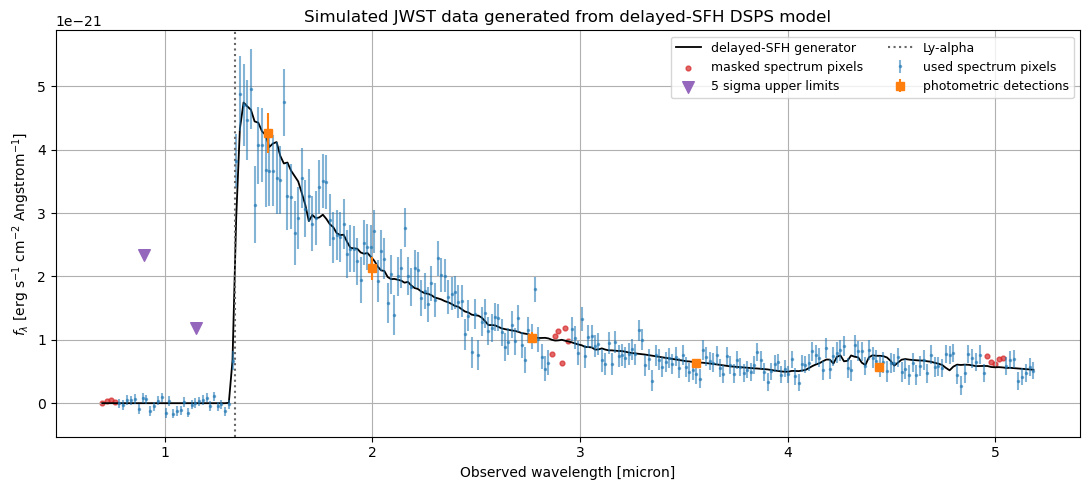

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
wave_um = spectral_wave_a / 1e4
ax.plot(wave_um, true_flux_pixel, color="black", lw=1.3, label="delayed-SFH generator")
ax.errorbar(wave_um[spectral_mask], observed_flux[spectral_mask], yerr=sigma_flux[spectral_mask], fmt=".", ms=3, alpha=0.55, label="used spectrum pixels")
ax.scatter(wave_um[~spectral_mask], observed_flux[~spectral_mask], s=12, color="tab:red", alpha=0.7, label="masked spectrum pixels")

phot_flam = maggies_to_flam_at_wave(phot_observed_maggies, filter_effective_wave_a)
phot_sigma_flam = maggies_to_flam_at_wave(phot_sigma_maggies, filter_effective_wave_a)
upper_flam = maggies_to_flam_at_wave(five_sigma_depth_maggies, filter_effective_wave_a)
is_det = ~upper_limit_mask
ax.errorbar(filter_effective_wave_a[is_det] / 1.0e4, phot_flam[is_det], yerr=phot_sigma_flam[is_det], fmt="s", ms=6, color="tab:orange", label="photometric detections")
ax.scatter(filter_effective_wave_a[upper_limit_mask] / 1.0e4, upper_flam[upper_limit_mask], marker="v", s=70, color="tab:purple", label="5 sigma upper limits")
ax.axvline(1215.67 * (1.0 + true_theta_gen[1]) / 1e4, color="0.4", ls=":", label="Ly-alpha")
ax.set_xlabel("Observed wavelength [micron]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Simulated JWST data generated from delayed-SFH DSPS model")
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()

## Initialize the continuity-SFH fit

`logsfr_0` is fixed to zero. The other `logsfr_i` parameters describe relative bin amplitudes.  This removes the exact additive degeneracy caused by normalizing every SFH to one solar mass formed.

In [6]:
def true_delayed_sfh_recent_to_old_bin_logsfr():
    """Approximate the delayed generator in the continuity bins for initialization only."""

    unscaled = model_gen.run_modules(jnp.asarray(true_theta_gen))
    t_obs = float(flat_lcdm_age_gyr_numpy(true_theta_gen[1]))
    time = np.asarray(unscaled.sfh_time_gyr)
    sfr = np.asarray(unscaled.sfr_msun_per_yr)
    lookback = t_obs - time
    full_edges = np.concatenate([lookback_edges_gyr, [t_obs]])
    binned = []
    for lo, hi in zip(full_edges[:-1], full_edges[1:]):
        inside = (lookback >= lo) & (lookback <= hi)
        if np.any(inside):
            binned.append(float(np.median(sfr[inside])))
        else:
            mid = 0.5 * (lo + hi)
            binned.append(float(np.interp(mid, lookback[::-1], sfr[::-1])))
    binned = np.asarray(binned)
    return np.log10(np.maximum(binned, 1e-300) / max(binned[0], 1e-300))


initial_relative_logsfr = true_delayed_sfh_recent_to_old_bin_logsfr()
initial_theta_fit = np.array([
    9.10,
    9.98,
    -0.60,
    0.09,
    1.10,
    *initial_relative_logsfr[1:],
])

init_table = pd.DataFrame(
    {
        "parameter": continuity_parameter_names,
        "initial": initial_theta_fit,
    }
)
init_table

,parameter,initial
0,log10_mass,9.100000
1,z,9.980000
2,logzsol,-0.600000
3,dust2,0.090000
4,line_scale,1.100000
5,logsfr_1,0.032704
6,logsfr_2,0.133321
7,logsfr_3,0.289446
8,logsfr_4,0.335827


## Run or load NUTS

The cached `.npz` stores both parameter samples and the posterior SFH draws on a common lookback grid.

In [7]:
def continuity_sfh_on_lookback_grid(theta, lookback_grid_gyr):
    """Physical SFR on a common lookback grid for one continuity-fit sample."""

    params = model_fit.params_from_theta(jnp.asarray(theta))
    z = float(params["z"])
    log10_mass = float(params["log10_mass"])
    t_obs = float(flat_lcdm_age_gyr_numpy(z))
    fixed_edges = lookback_edges_gyr.copy()

    # Match the clipping logic in continuity_sfh_cosmic_time_module.
    n_fixed = fixed_edges.size
    min_width = min(1.0e-4, t_obs / (10.0 * n_fixed))
    max_fixed_edges = t_obs - min_width * (n_fixed - np.arange(n_fixed))
    clipped = np.minimum(fixed_edges, max_fixed_edges)
    clipped[0] = 0.0
    full_edges = np.concatenate([clipped, [t_obs]])

    logsfr = np.array([float(params[f"logsfr_{i}"]) for i in range(n_fixed)])
    sfr_recent_to_old = 10.0**logsfr
    widths = full_edges[1:] - full_edges[:-1]
    sfr_recent_to_old = sfr_recent_to_old / np.sum(sfr_recent_to_old * widths * 1.0e9)
    physical_sfr = sfr_recent_to_old * 10.0**log10_mass

    out = np.full_like(lookback_grid_gyr, np.nan, dtype=float)
    for i, (lo, hi) in enumerate(zip(full_edges[:-1], full_edges[1:])):
        inside = (lookback_grid_gyr >= lo) & (lookback_grid_gyr < hi)
        out[inside] = physical_sfr[i]
    out[np.isclose(lookback_grid_gyr, full_edges[-1])] = physical_sfr[-1]
    return out


def delayed_truth_sfh_on_lookback_grid(lookback_grid_gyr):
    unscaled = model_gen.run_modules(jnp.asarray(true_theta_gen))
    t_obs = float(flat_lcdm_age_gyr_numpy(true_theta_gen[1]))
    time = np.asarray(unscaled.sfh_time_gyr)
    sfr = np.asarray(unscaled.sfr_msun_per_yr) * 10.0 ** true_theta_gen[0]
    lookback = t_obs - time
    order = np.argsort(lookback)
    return np.interp(lookback_grid_gyr, lookback[order], sfr[order], left=np.nan, right=np.nan)


lookback_grid_gyr = np.linspace(0.0, 0.56, 180)

if RUN_NUTS:
    t0 = time.perf_counter()
    nuts_result = run_numpyro_nuts(
        model=model_fit,
        data=joint_data,
        initial_theta=jnp.asarray(initial_theta_fit),
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        rng_seed=29,
        progress_bar=True,
        target_accept_prob=0.95,
        max_tree_depth=8,
        dense_mass=True,
    )
    runtime = time.perf_counter() - t0
    samples = nuts_result.samples
    sfh_draws = np.asarray([continuity_sfh_on_lookback_grid(theta, lookback_grid_gyr) for theta in samples])
    true_sfh_grid = delayed_truth_sfh_on_lookback_grid(lookback_grid_gyr)
    np.savez(
        FIT_FILE,
        samples=samples,
        log_prob=nuts_result.log_prob,
        theta_names=np.asarray(nuts_result.theta_names),
        generator_theta_names=np.asarray(base_parameter_names),
        truth_gen=true_theta_gen,
        fixed_generator_sfh=np.asarray([fixed_generator_sfh["tau_gyr"], fixed_generator_sfh["tage_fraction"]]),
        initial_theta=initial_theta_fit,
        lookback_edges_gyr=lookback_edges_gyr,
        lookback_grid_gyr=lookback_grid_gyr,
        sfh_draws_msun_per_yr=sfh_draws,
        true_sfh_msun_per_yr=true_sfh_grid,
        spectral_wave_a=spectral_wave_a,
        spectral_edges_a=spectral_edges_a,
        resolving_power=resolving_power,
        observed_flux=observed_flux,
        sigma_flux=sigma_flux,
        spectral_mask=spectral_mask,
        true_flux_pixel=true_flux_pixel,
        true_phot_maggies=true_phot_maggies,
        phot_observed_maggies=phot_observed_maggies,
        phot_sigma_maggies=phot_sigma_maggies,
        upper_limit_maggies=five_sigma_depth_maggies,
        upper_limit_mask=upper_limit_mask,
        filter_effective_wave_a=filter_effective_wave_a,
        runtime_seconds=np.asarray(runtime),
    )
    extra = nuts_result.extra_fields.get("numpyro", {})
    summary = {
        "runtime_seconds": float(runtime),
        "n_samples": int(samples.shape[0]),
        "jax_backend": jax.default_backend(),
        "accept_prob_mean": float(np.mean(np.asarray(extra.get("accept_prob", np.nan)))),
        "n_divergences": int(np.sum(np.asarray(extra.get("diverging", [])))) if "diverging" in extra else None,
        "n_spectral_pixels": int(spectral_mask.size),
        "n_active_spectral_pixels": int(spectral_mask.sum()),
        "n_photometric_bands": int(len(filters.names)),
        "n_upper_limits": int(upper_limit_mask.sum()),
    }
    SUMMARY_FILE.write_text(json.dumps(summary, indent=2))
else:
    print("Loading existing fit", FIT_FILE)

fit = np.load(FIT_FILE, allow_pickle=True)
samples = fit["samples"]
log_prob = fit["log_prob"]
theta_names = [str(x) for x in fit["theta_names"]]
runtime = float(fit["runtime_seconds"])
sfh_draws = fit["sfh_draws_msun_per_yr"]
true_sfh_grid = fit["true_sfh_msun_per_yr"]
lookback_grid_gyr = fit["lookback_grid_gyr"]
print(f"Loaded samples: {samples.shape}")
print(f"Runtime: {runtime:.2f} s")
if SUMMARY_FILE.exists():
    print(SUMMARY_FILE.read_text())

  0%|          | 0/550 [00:00<?, ?it/s]

warmup:   0%|          | 0/550 [00:10<?, ?it/s, 255 steps of size 2.91e-03. acc. prob=0.66]

warmup:   2%|▏         | 10/550 [00:11<10:25,  1.16s/it, 255 steps of size 3.35e-03. acc. prob=0.70]

warmup:   2%|▏         | 11/550 [00:13<11:46,  1.31s/it, 255 steps of size 3.56e-03. acc. prob=0.72]

warmup:   2%|▏         | 12/550 [00:16<13:11,  1.47s/it, 255 steps of size 4.04e-03. acc. prob=0.74]

...

sample: 100%|█████████▉| 548/550 [21:40<00:04,  2.32s/it, 255 steps of size 1.11e-02. acc. prob=0.95]

sample: 100%|█████████▉| 549/550 [21:42<00:02,  2.32s/it, 255 steps of size 1.11e-02. acc. prob=0.95]

sample: 100%|██████████| 550/550 [21:45<00:00,  2.32s/it, 255 steps of size 1.11e-02. acc. prob=0.95]

sample: 100%|██████████| 550/550 [21:45<00:00,  2.37s/it, 255 steps of size 1.11e-02. acc. prob=0.95]

Loaded samples: (500, 9)
Runtime: 1326.87 s
{
  "runtime_seconds": 1326.8731745828409,
  "n_samples": 500,
  "jax_backend": "cpu",
  "accept_prob_mean": 0.954765853359558,
  "n_divergences": 0,
  "n_spectral_pixels": 265,
  "n_active_spectral_pixels": 250,
  "n_photometric_bands": 7,
  "n_upper_limits": 2
}


## Parameter posterior

In [8]:
rows = []
truth_lookup = dict(zip(base_parameter_names, true_theta_gen))
truth_lookup.update({"logsfr_0": 0.0})
for i, name in enumerate(theta_names):
    q16, q50, q84 = np.percentile(samples[:, i], [16, 50, 84])
    rows.append(
        {
            "parameter": name,
            "truth_or_generator": truth_lookup.get(name, np.nan),
            "median": q50,
            "minus": q50 - q16,
            "plus": q84 - q50,
        }
    )
summary_table = pd.DataFrame(rows)
summary_table

,parameter,truth_or_generator,median,minus,plus
0,log10_mass,9.15,8.906724,0.159352,0.174954
1,z,10.00,9.988686,0.011170,0.014527
2,logzsol,-0.65,-0.608114,0.163050,0.179624
3,dust2,0.08,0.125886,0.078473,0.065874
4,line_scale,1.25,1.499035,1.008875,0.909733
5,logsfr_1,NaN,-0.420506,1.475391,1.761210
6,logsfr_2,NaN,-0.100134,0.827307,0.730195
7,logsfr_3,NaN,-1.225774,1.046195,1.120906
8,logsfr_4,NaN,-0.867425,0.710463,0.888109


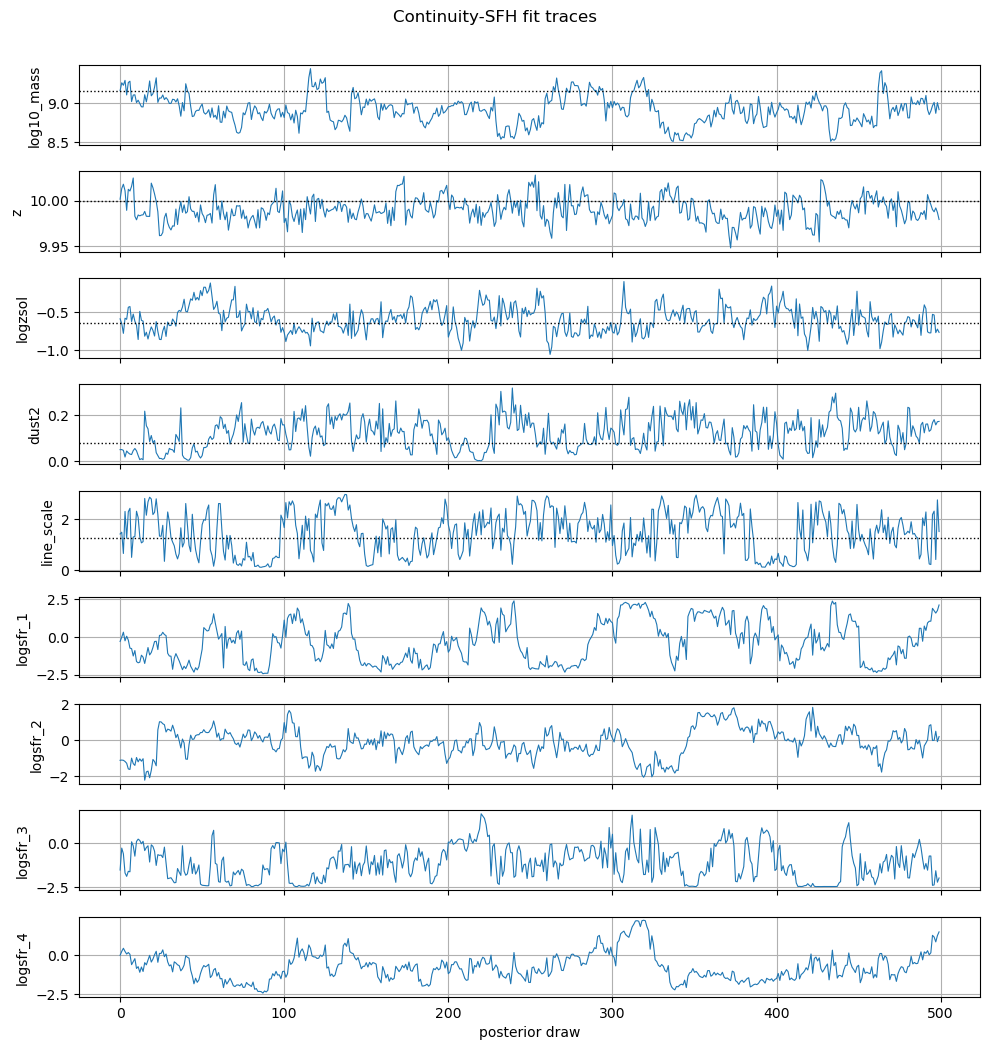

In [9]:
n_param = len(theta_names)
fig, axes = plt.subplots(n_param, 1, figsize=(10, 1.15 * n_param), sharex=True)
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.plot(samples[:, i], lw=0.8)
    if theta_names[i] in truth_lookup and np.isfinite(truth_lookup[theta_names[i]]):
        ax.axhline(truth_lookup[theta_names[i]], color="black", ls=":", lw=1)
    ax.set_ylabel(theta_names[i])
axes[-1].set_xlabel("posterior draw")
fig.suptitle("Continuity-SFH fit traces", y=1.01)
fig.tight_layout()

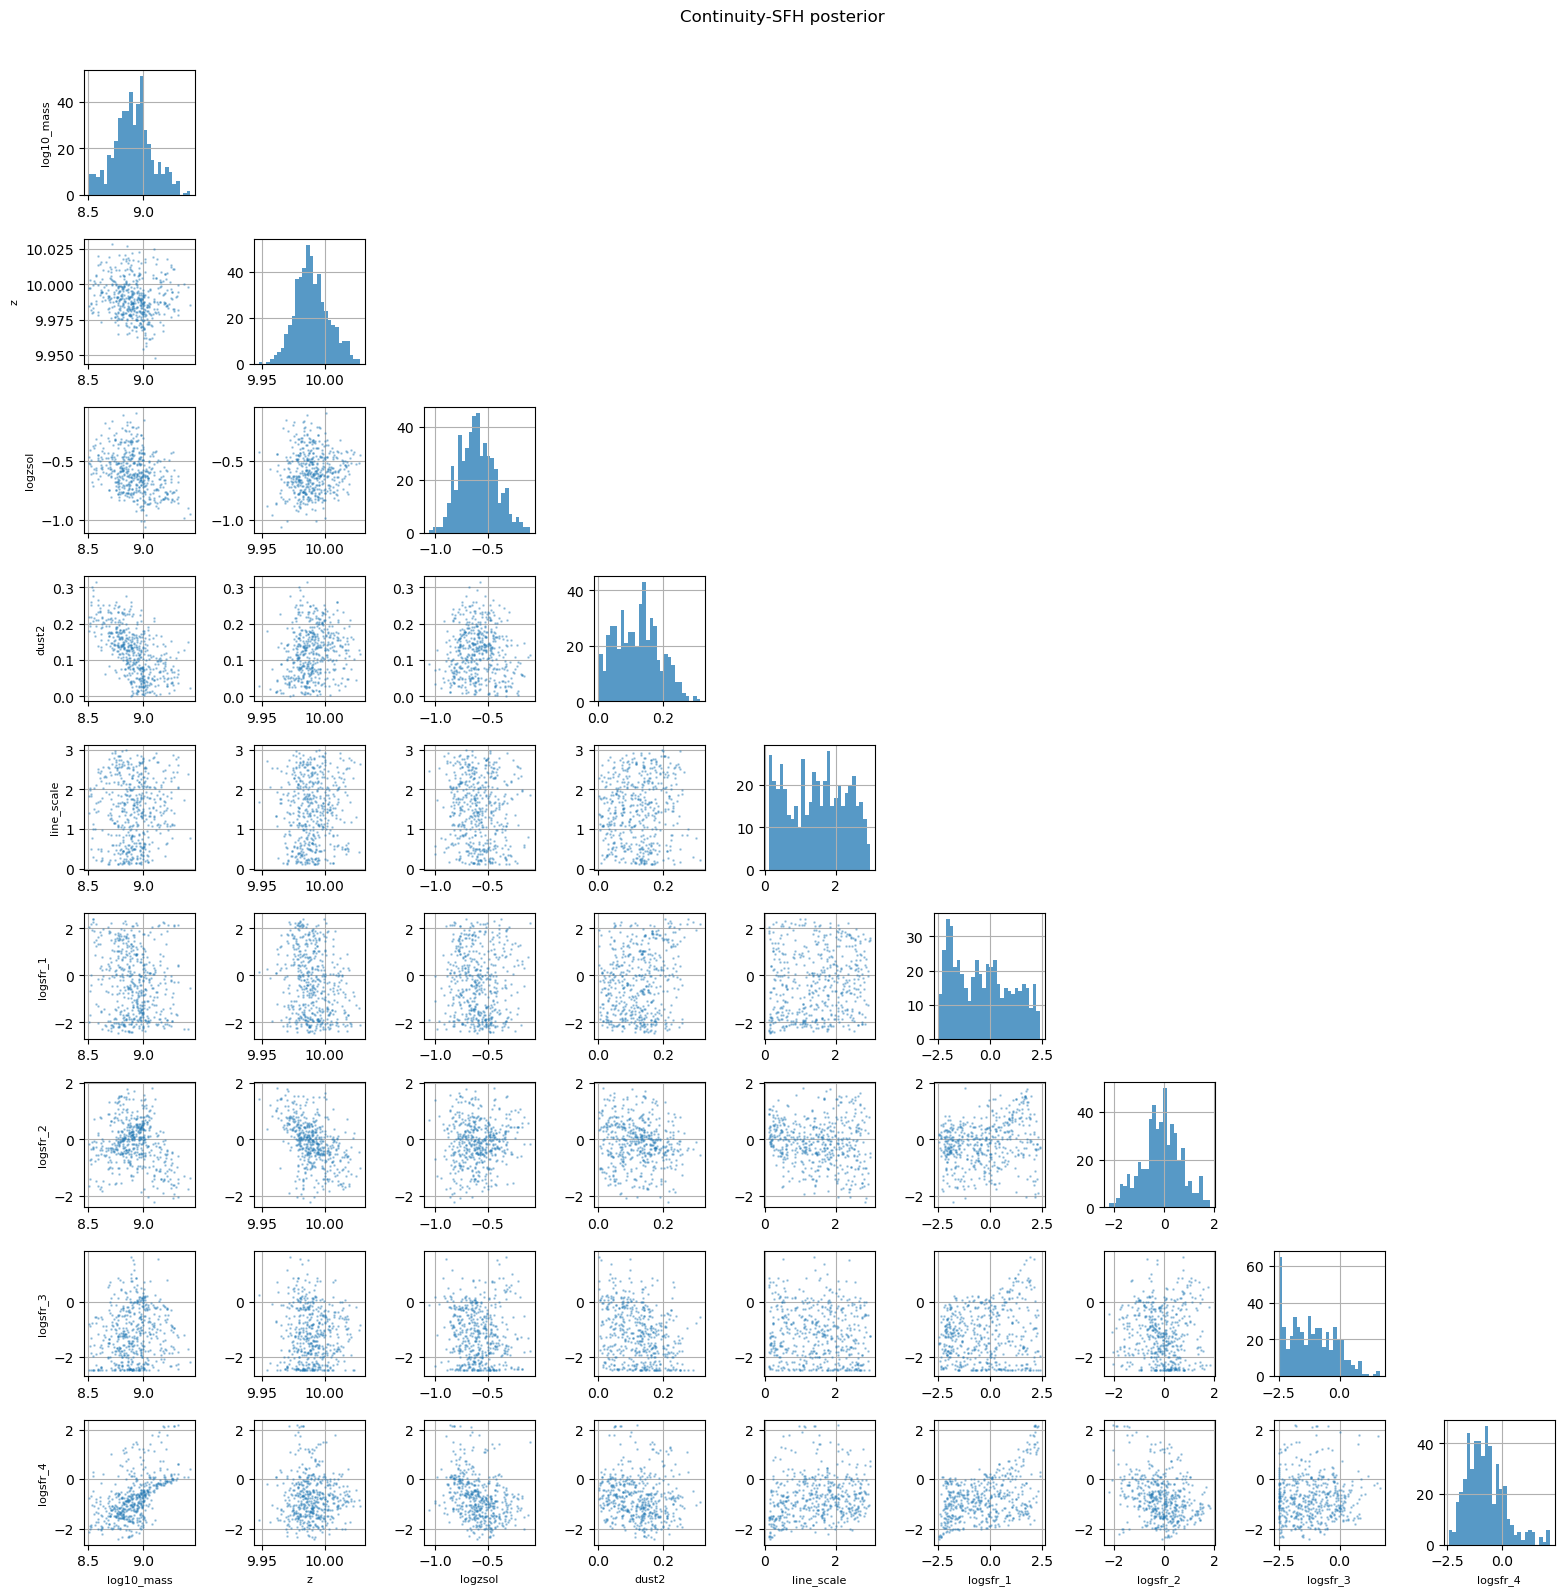

In [10]:
fig, axes = plt.subplots(n_param, n_param, figsize=(1.75 * n_param, 1.75 * n_param))
for i in range(n_param):
    for j in range(n_param):
        ax = axes[i, j]
        if i == j:
            ax.hist(samples[:, i], bins=28, color="tab:blue", alpha=0.75)
        elif i > j:
            ax.plot(samples[:, j], samples[:, i], ".", ms=1.8, alpha=0.32)
        else:
            ax.axis("off")
        if i == n_param - 1 and j <= i:
            ax.set_xlabel(theta_names[j], fontsize=8)
        if j == 0 and i >= j:
            ax.set_ylabel(theta_names[i], fontsize=8)
fig.suptitle("Continuity-SFH posterior", y=1.01)
fig.tight_layout()

## SFH posterior

The plotted SFH is physical `Msun / yr`: the continuity module returns a per-formed-solar-mass SFH, then the notebook multiplies each draw by `10**log10_mass`.

/Users/gregoire/miniforge3/envs/dsps_nuts/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


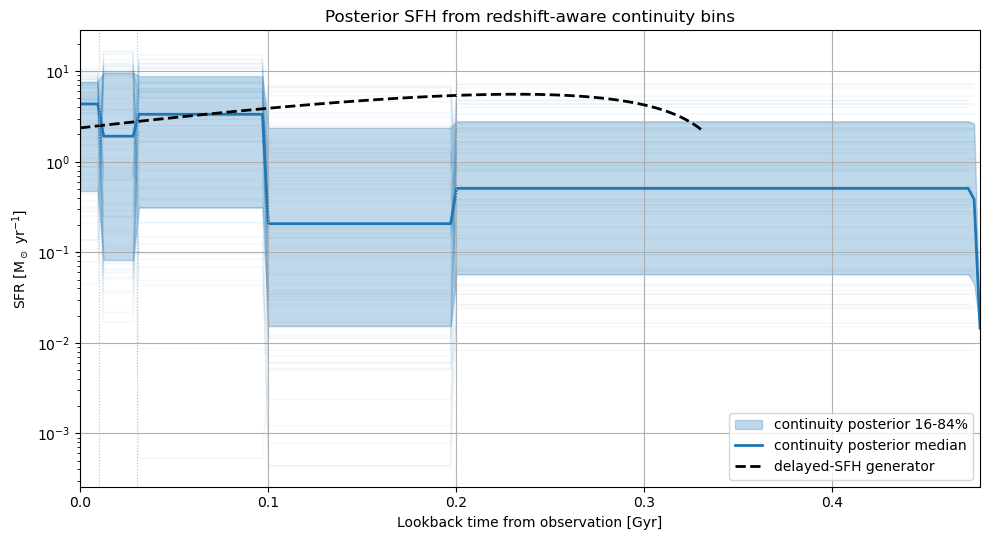

In [11]:
sfh_q16, sfh_q50, sfh_q84 = np.nanpercentile(sfh_draws, [16, 50, 84], axis=0)
valid_truth = np.isfinite(true_sfh_grid)
valid_post = np.isfinite(sfh_q50)

fig, ax = plt.subplots(figsize=(10, 5.5))
for draw in sfh_draws[np.linspace(0, sfh_draws.shape[0] - 1, min(70, sfh_draws.shape[0]), dtype=int)]:
    ax.plot(lookback_grid_gyr, draw, color="tab:blue", alpha=0.05, lw=1)
ax.fill_between(lookback_grid_gyr[valid_post], sfh_q16[valid_post], sfh_q84[valid_post], color="tab:blue", alpha=0.28, label="continuity posterior 16-84%")
ax.plot(lookback_grid_gyr[valid_post], sfh_q50[valid_post], color="tab:blue", lw=2, label="continuity posterior median")
ax.plot(lookback_grid_gyr[valid_truth], true_sfh_grid[valid_truth], color="black", lw=2, ls="--", label="delayed-SFH generator")
for edge in lookback_edges_gyr[1:]:
    ax.axvline(edge, color="0.75", lw=0.8, ls=":")
ax.set_yscale("log")
ax.set_xlim(0.0, np.nanmax(lookback_grid_gyr[valid_post]))
ax.set_xlabel("Lookback time from observation [Gyr]")
ax.set_ylabel(r"SFR [M$_\odot$ yr$^{-1}$]")
ax.set_title("Posterior SFH from redshift-aware continuity bins")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "continuity_sfh_posterior.png", dpi=180)

## Posterior predictive data check

In [12]:
def pixel_model_for_theta(theta):
    state = model_fit.run_modules_mass_scaled(jnp.asarray(theta))
    return np.asarray(
        model_spectrum_on_observed_pixels(
            state.wave_obs_a,
            state.flux_lambda_cgs,
            jnp.asarray(spectral_wave_a),
            jnp.asarray(spectral_edges_a),
            resample_mode="bin",
            resolving_power=resolving_power,
        )
    )

predict_photometry_jit = jax.jit(model_fit.predict_photometry)

def photometry_for_theta(theta):
    return np.asarray(predict_photometry_jit(jnp.asarray(theta)))

subset = samples[np.linspace(0, samples.shape[0] - 1, min(70, samples.shape[0]), dtype=int)]
pred_spec = np.asarray([pixel_model_for_theta(theta) for theta in subset])
pred_phot = np.asarray([photometry_for_theta(theta) for theta in subset])
spec_q16, spec_q50, spec_q84 = np.percentile(pred_spec, [16, 50, 84], axis=0)
phot_q16, phot_q50, phot_q84 = np.percentile(pred_phot, [16, 50, 84], axis=0)
residual_sigma = (observed_flux - spec_q50) / sigma_flux
phot_residual_sigma = (phot_observed_maggies - phot_q50) / phot_sigma_maggies

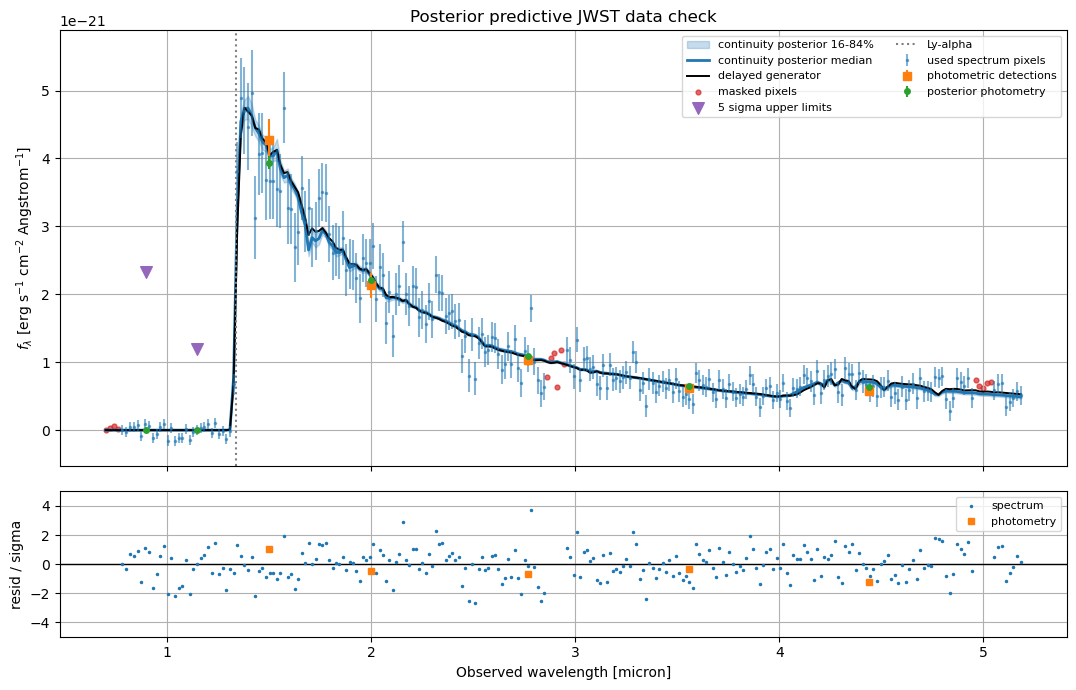

In [13]:
fig, (ax, rx) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
wave_um = spectral_wave_a / 1e4
ax.fill_between(wave_um, spec_q16, spec_q84, color="tab:blue", alpha=0.25, label="continuity posterior 16-84%")
ax.plot(wave_um, spec_q50, color="tab:blue", lw=2, label="continuity posterior median")
ax.plot(wave_um, true_flux_pixel, color="black", lw=1.4, label="delayed generator")
ax.errorbar(wave_um[spectral_mask], observed_flux[spectral_mask], yerr=sigma_flux[spectral_mask], fmt=".", ms=3, alpha=0.55, label="used spectrum pixels")
ax.scatter(wave_um[~spectral_mask], observed_flux[~spectral_mask], s=12, color="tab:red", alpha=0.7, label="masked pixels")

phot_flam = maggies_to_flam_at_wave(phot_observed_maggies, filter_effective_wave_a)
phot_sigma_flam = maggies_to_flam_at_wave(phot_sigma_maggies, filter_effective_wave_a)
upper_flam = maggies_to_flam_at_wave(five_sigma_depth_maggies, filter_effective_wave_a)
phot_flam_q50 = maggies_to_flam_at_wave(phot_q50, filter_effective_wave_a)
phot_flam_q16 = maggies_to_flam_at_wave(phot_q16, filter_effective_wave_a)
phot_flam_q84 = maggies_to_flam_at_wave(phot_q84, filter_effective_wave_a)
phot_yerr = np.vstack([phot_flam_q50 - phot_flam_q16, phot_flam_q84 - phot_flam_q50])
is_det = ~upper_limit_mask
ax.errorbar(filter_effective_wave_a[is_det] / 1e4, phot_flam[is_det], yerr=phot_sigma_flam[is_det], fmt="s", ms=6, color="tab:orange", label="photometric detections")
ax.errorbar(filter_effective_wave_a / 1e4, phot_flam_q50, yerr=phot_yerr, fmt="o", ms=4, color="tab:green", label="posterior photometry")
ax.scatter(filter_effective_wave_a[upper_limit_mask] / 1e4, upper_flam[upper_limit_mask], marker="v", s=70, color="tab:purple", label="5 sigma upper limits")
ax.axvline(1215.67 * (1.0 + true_theta_gen[1]) / 1e4, color="0.5", ls=":", label="Ly-alpha")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Posterior predictive JWST data check")
ax.legend(ncol=2, fontsize=8)

rx.axhline(0.0, color="black", lw=1)
rx.plot(wave_um[spectral_mask], residual_sigma[spectral_mask], ".", ms=3, label="spectrum")
rx.errorbar(filter_effective_wave_a[is_det] / 1e4, phot_residual_sigma[is_det], fmt="s", ms=5, color="tab:orange", label="photometry")
rx.set_xlabel("Observed wavelength [micron]")
rx.set_ylabel("resid / sigma")
rx.set_ylim(-5, 5)
rx.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "continuity_posterior_predictive.png", dpi=180)

In [14]:
active_residual = residual_sigma[spectral_mask]
metrics = {
    "n_spectral_pixels": int(spectral_mask.size),
    "n_active_spectral_pixels": int(spectral_mask.sum()),
    "n_photometric_bands": int(len(filters.names)),
    "n_upper_limits": int(upper_limit_mask.sum()),
    "spectrum_median_abs_residual_sigma": float(np.median(np.abs(active_residual))),
    "spectrum_rms_residual_sigma": float(np.sqrt(np.mean(active_residual**2))),
    "phot_detection_rms_residual_sigma": float(np.sqrt(np.mean(phot_residual_sigma[is_det] ** 2))),
    "runtime_seconds": float(runtime),
}
metrics

{'n_spectral_pixels': 265,
 'n_active_spectral_pixels': 250,
 'n_photometric_bands': 7,
 'n_upper_limits': 2,
 'spectrum_median_abs_residual_sigma': 0.6618398027576403,
 'spectrum_rms_residual_sigma': 1.0299833287861073,
 'phot_detection_rms_residual_sigma': 0.8282678919857339,
 'runtime_seconds': 1326.8731745828409}

## Audit notes

1. **Data entering**: one simulated JWST-like spectrum and seven broad-band fluxes generated from a delayed-SFH DSPS model.
2. **Transformations**: the fitter replaces the delayed SFH with redshift-aware continuity bins, then uses the same DSPS stellar, toy nebular, dust, IGM, redshift, spectral response, and photometry code.
3. **Units**: spectra are cgs `f_lambda`; photometry is maggies; SFH is plotted as physical `Msun/yr` after multiplying by `10**log10_mass`.
4. **Masks/cuts**: spectral masks are explicit; `F090W` and `F115W` are upper limits via Gaussian CDF terms.
5. **Normalization**: each SFH is normalized to one solar mass formed; mass scaling is applied once through `log10_mass`.
6. **Final quantity**: joint posterior over base SED parameters plus relative continuity-bin SFR amplitudes.
7. **Most important lines to check**: the two model definitions, `continuity_sfh_on_lookback_grid`, and the `GaussianSpectroPhotometricData` construction.
8. **Sanity check**: the continuity-SFH posterior should bracket the delayed-SFH generator at the coarse-bin level, not reproduce its smooth curve exactly.